# Visualizing `generate_trace_dfs` — v21 N-gram Shadow Log Generation

This notebook visualizes the recursive DFS trace generator used in `HybridGen/algorithm/v21.py`.

**Key concepts:**
- **DFS Trace Walker**: Recursively builds a trace one activity at a time
- **Katz Backoff**: Tries N=3 → N=2 → N=1, falling back when data is sparse
- **Mutation vs Exploit**: `P_unseen` controls how often the walker explores unseen paths
- **Termination Check**: Ends trace probabilistically based on historical end frequency

In [1]:
import random
import numpy as np
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11,
    'axes.titlesize': 13, 'axes.labelsize': 11
})

import pm4py

# Load the Sepsis log (experiment utils convention)
log = pm4py.read_xes("data/Sepsis Cases - Event Log_1_all/Sepsis Cases - Event Log.xes.gz")
log = pm4py.convert_to_event_log(log)
print(f"Log: {len(log)} traces")

# Pre-compute N-gram statistics
max_n = 3
ngram_outgoings = {n: defaultdict(Counter) for n in range(1, max_n + 1)}
starts, ends = Counter(), Counter()
alphabet = set()

for trace in log:
    seq = [e["concept:name"] for e in trace]
    starts[seq[0]] += 1
    ends[seq[-1]] += 1
    alphabet.update(seq)
    for i in range(len(seq) - 1):
        nxt = seq[i + 1]
        for n in range(1, max_n + 1):
            if i >= n - 1:
                state = tuple(seq[i - (n - 1) : i + 1])
                ngram_outgoings[n][state][nxt] += 1

alphabet = list(alphabet)
print(f"Alphabet: {len(alphabet)} activities")
for n in range(1, max_n + 1):
    print(f"  N={n}: {len(ngram_outgoings[n])} states")

/home/gengtianhao/Process Mining/.venv/lib/python3.12/site-packages/pm4py/utils.py:1005: UserWarning: In the current version, the import/export operation uses `r4pm` by default for importing/exporting files faster.
  warnings.warn(


Log: 1050 traces
Alphabet: 16 activities
  N=1: 16 states
  N=2: 99 states
  N=3: 358 states


---
## 1. Algorithm Flowchart: Decision Tree of `generate_trace_dfs`

Each call to `generate_trace_dfs` makes four sequential decisions:

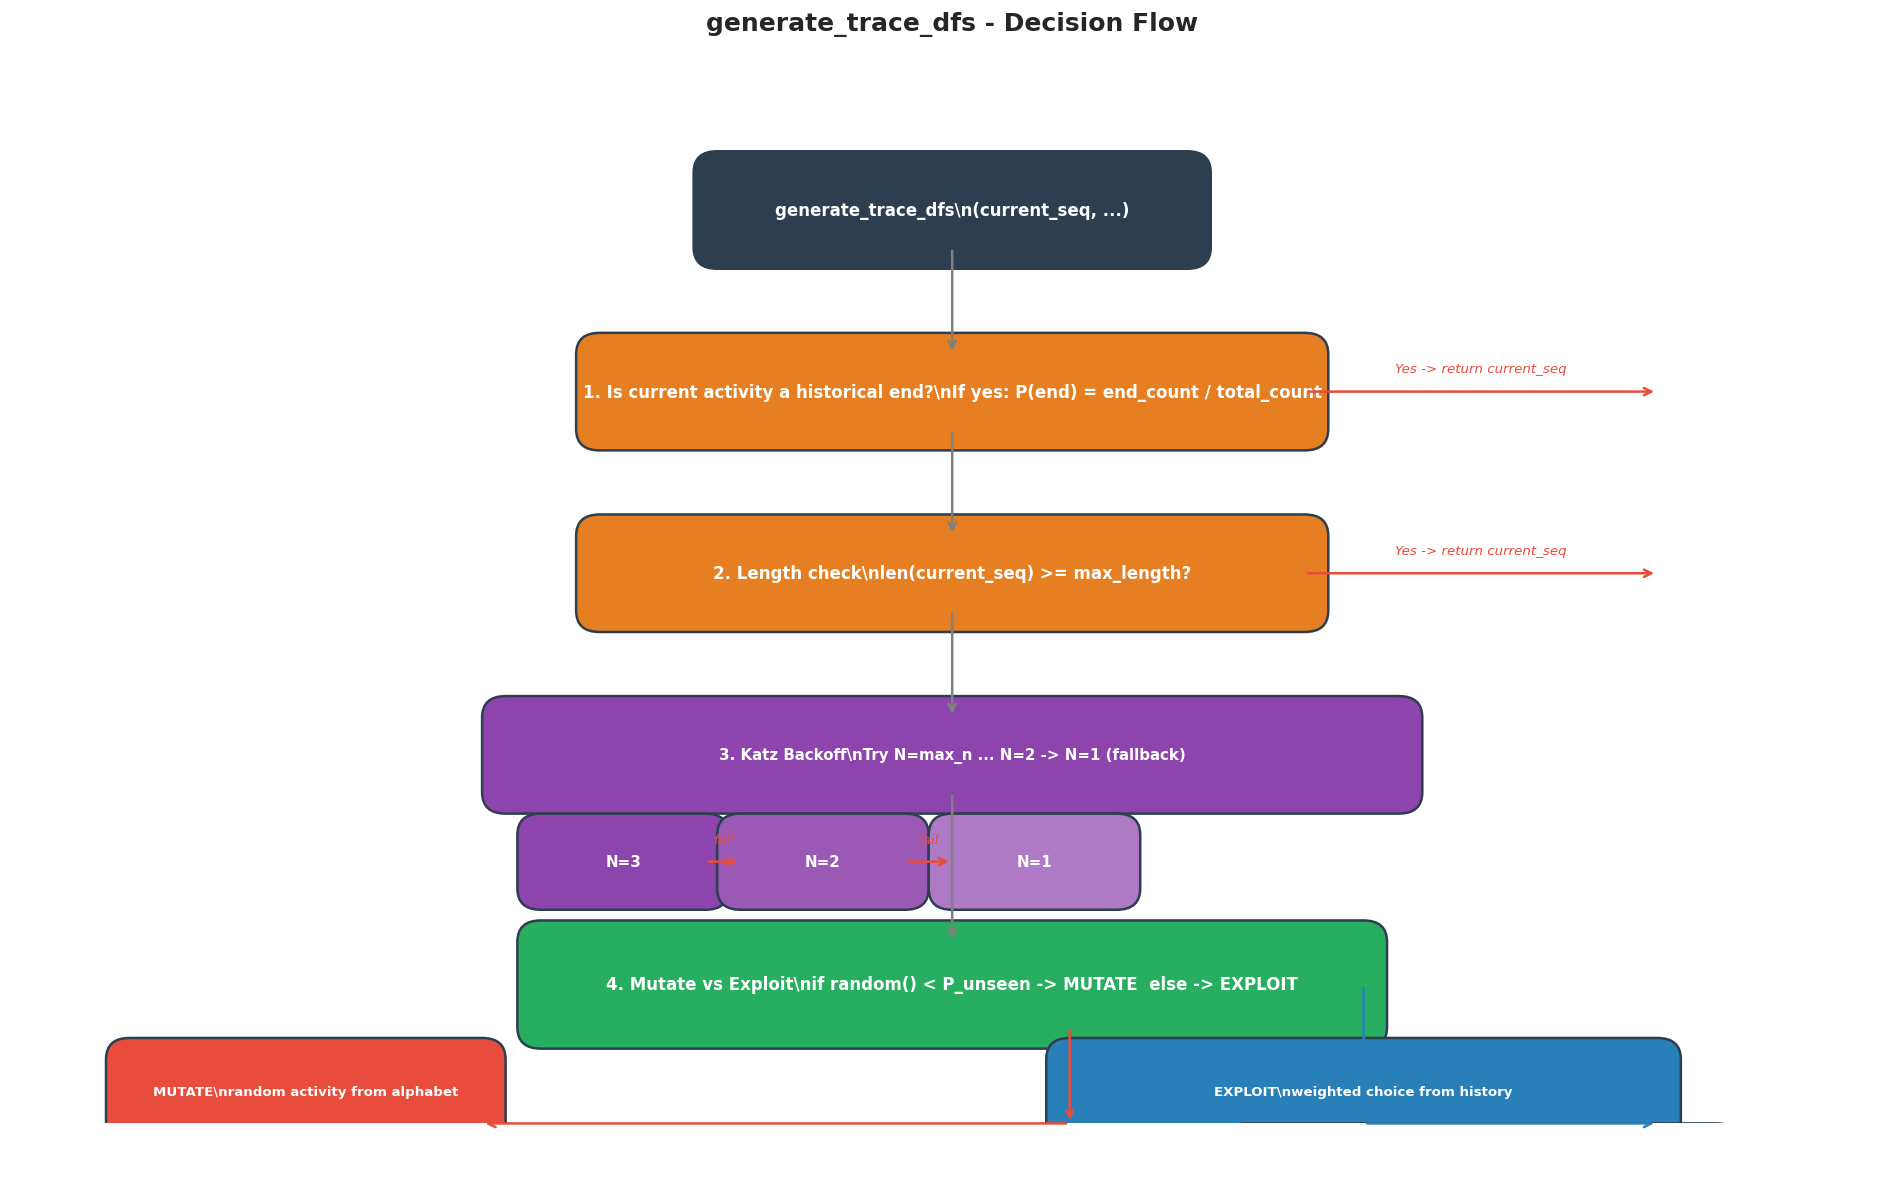

In [2]:
fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 16); ax.set_ylim(0, 10)
ax.axis('off')

def box(x, y, w, h, text, color='#3498DB', text_color='white', size=10):
    rect = mpatches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.2",
                                    facecolor=color, edgecolor='#2C3E50', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=size,
            fontweight='bold', color=text_color)

def arrow(x1, y1, x2, y2, label='', color='gray'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2 + 0.15
        ax.text(mx, my, label, ha='center', va='bottom', fontsize=8, color=color, style='italic')

box(6, 8.2, 4, 0.7, 'generate_trace_dfs\\n(current_seq, ...)', '#2C3E50')

d1x, d1y = 5, 6.5
box(d1x, d1y, 6, 0.7, '1. Is current activity a historical end?\\nIf yes: P(end) = end_count / total_count', '#E67E22')
arrow(8, 8.2, 8, 7.2)
arrow(8, 7.2, d1x + 3, d1y + 0.7)
arrow(d1x + 6, d1y + 0.35, 14, d1y + 0.35, 'Yes -> return current_seq', '#E74C3C')

d2x, d2y = 5, 4.8
box(d2x, d2y, 6, 0.7, '2. Length check\\nlen(current_seq) >= max_length?', '#E67E22')
arrow(d1x + 3, d1y, d2x + 3, d2y + 0.7)
arrow(d2x + 6, d2y + 0.35, 14, d2y + 0.35, 'Yes -> return current_seq', '#E74C3C')

d3x, d3y = 4.2, 3.1
box(d3x, d3y, 7.6, 0.7,
     '3. Katz Backoff\\nTry N=max_n ... N=2 -> N=1 (fallback)', '#8E44AD', size=9)
arrow(d2x + 3, d2y, d3x + 3.8, d3y + 0.7)

sub_x = [4.5, 6.2, 8.0]
for i, (n, clr) in enumerate([(3, '#8E44AD'), (2, '#9B59B6'), (1, '#AF7AC5')]):
    box(sub_x[i], 2.2, 1.4, 0.5, f'N={n}', clr, size=9)
    if i < 2:
        arrow(sub_x[i]+1.4, 2.45, sub_x[i+1], 2.45, 'fail', '#E74C3C')

d4x, d4y = 4.5, 0.9
box(d4x, d4y, 7, 0.8,
     '4. Mutate vs Exploit\\nif random() < P_unseen -> MUTATE  else -> EXPLOIT',
     '#27AE60')
arrow(d3x + 3.8, d3y, d4x + 3.5, d4y + 0.8)

box(1, 0.0, 3, 0.6, 'MUTATE\\nrandom activity from alphabet', '#E74C3C', size=8)
arrow(d4x + 4.5, d4y, d4x + 4.5, 0.0, '', '#E74C3C')
arrow(d4x + 4.5, 0.0, 4, 0.0, '', '#E74C3C')

box(9, 0.0, 5, 0.6, 'EXPLOIT\\nweighted choice from history', '#2980B9', size=8)
arrow(d4x + 7, d4y + 0.4, 11.5, d4y + 0.4, '', '#2980B9')
arrow(11.5, d4y + 0.4, 11.5, 0.0, '', '#2980B9')
arrow(11.5, 0.0, 14, 0.0, '', '#2980B9')

box(10.5, -0.7, 4, 0.5, 'Recurse with\\ncurrent_seq + [next_node]', '#2C3E50', size=8)
arrow(12.5, 0.0, 12.5, -0.7)

ax.set_title('generate_trace_dfs - Decision Flow', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 2. Katz Backoff in Action

The algorithm tries N=3 first (highest context). If the state is too **sparse** (total transitions < `safe_threshold=5`) or has **P_unseen = 1.0**, it **backoffs** to N=2, then to N=1.

In [3]:
def trace_backoff_example(seq_prefix, ngram_outgoings, max_n=3, safe_threshold=5):
    results = []
    for n in range(max_n, 0, -1):
        if n == 1:
            state = (seq_prefix[-1],)
            out_edges = ngram_outgoings[1].get(state, {})
            n_total = sum(out_edges.values())
            n_1 = sum(1 for c in out_edges.values() if c == 1)
            p_unseen = (n_1 / n_total) if n_total > 0 else 1.0
            status = 'FALLBACK (always available)'
            results.append((n, state, n_total, n_1, p_unseen, status))
        elif len(seq_prefix) >= n:
            state = tuple(seq_prefix[-n:])
            out_edges = ngram_outgoings[n].get(state, {})
            n_total = sum(out_edges.values())
            if n_total < safe_threshold:
                status = f'BACKOFF (n_total={n_total} < {safe_threshold})'
            else:
                n_1 = sum(1 for c in out_edges.values() if c == 1)
                p_unseen = (n_1 / n_total) if n_total > 0 else 1.0
                if p_unseen == 1.0:
                    status = f'BACKOFF (P_unseen=1.0)'
                else:
                    top = max(out_edges, key=out_edges.get)
                    status = f'SELECTED -> {top} (p={p_unseen:.3f}, n_total={n_total})'
            n_1 = sum(1 for c in out_edges.values() if c == 1) if out_edges else 0
            p_unseen = (n_1 / n_total) if n_total > 0 else 1.0
            results.append((n, state, n_total, n_1, p_unseen, status))
        else:
            results.append((n, tuple(), 0, 0, 1.0, f'SKIP (seq too short, need {n})'))
    return results

random.seed(42)
start_node = random.choices(list(starts.keys()), weights=list(starts.values()), k=1)[0]
seq = [start_node]

print(f"Starting trace with: '{start_node}'")
for step in range(5):
    print(f"\\n{'='*70}")
    print(f"Step {step+1}: current_seq = {seq}")
    print(f"{'='*70}")
    backoff_results = trace_backoff_example(seq, ngram_outgoings)
    for n, state, n_total, n_1, p_u, status in backoff_results:
        state_str = f"state={' -> '.join(state)}" if state else "N/A"
        print(f"  N={n}: {status:55s} | {state_str}")
    out_edges = ngram_outgoings[1].get((seq[-1],), {})
    if out_edges:
        next_act = random.choices(list(out_edges.keys()),
                                  weights=[np.log(c+1) for c in out_edges.values()], k=1)[0]
        seq.append(next_act)
        print(f"  -> Chose: '{next_act}'")
    else:
        print(f"  -> No more edges, terminating")
        break

Starting trace with: 'ER Registration'
\n======================================================================
Step 1: current_seq = ['ER Registration']
  N=3: SKIP (seq too short, need 3)                            | N/A
  N=2: SKIP (seq too short, need 2)                            | N/A
  N=1: FALLBACK (always available)                             | state=ER Registration
  -> Chose: 'Leucocytes'
\n======================================================================
Step 2: current_seq = ['ER Registration', 'Leucocytes']
  N=3: SKIP (seq too short, need 3)                            | N/A
  N=2: SELECTED -> CRP (p=0.000, n_total=21)                   | state=ER Registration -> Leucocytes
  N=1: FALLBACK (always available)                             | state=Leucocytes
  -> Chose: 'Release A'
\n======================================================================
Step 3: current_seq = ['ER Registration', 'Leucocytes', 'Release A']
  N=3: BACKOFF (n_total=0 < 5)                   

## 3. Mutated Trace Generation Demo

Using **seed=26** which produces a **mutation** at Step 10: `ER Triage` has P_unseen=0.083 at N=3; roll=0.031 < 0.083 triggers mutation to `Release B` (randomly chosen from the full alphabet).

In [4]:
random.seed(26)
start_node = random.choices(list(starts.keys()), weights=list(starts.values()), k=1)[0]

def gen_trace_verbose(current_seq, ngram_outgoings, ends, alphabet, max_length, safe_threshold, max_n, had_mutation=False, history=None):
    if history is None:
        history = []
    current_local = current_seq[-1]
    if current_local in ends:
        times_as_end = ends[current_local]
        out_edges_n1 = ngram_outgoings[1].get((current_local,), {})
        total_occ = times_as_end + sum(out_edges_n1.values())
        end_prob = times_as_end / total_occ
        if random.random() < end_prob:
            history.append((len(current_seq), current_seq[-1],
                           '', '', 'TERMINATE', '', f'P_end={end_prob:.3f}'))
            return current_seq, had_mutation, history
    if len(current_seq) >= max_length:
        return current_seq, had_mutation, history
    chosen_n, p_unseen, valid_out_edges = None, None, None
    for n in range(max_n, 1, -1):
        if len(current_seq) >= n:
            state = tuple(current_seq[-n:])
            out_edges = ngram_outgoings[n].get(state, {})
            n_total = sum(out_edges.values())
            if n_total >= safe_threshold:
                n_1 = sum(1 for c in out_edges.values() if c == 1)
                p = (n_1 / n_total) if n_total > 0 else 1.0
                if p < 1.0:
                    p_unseen, valid_out_edges, chosen_n = p, out_edges, n
                    break
    if chosen_n is None:
        out_edges = ngram_outgoings[1].get((current_local,), {})
        n_total = sum(out_edges.values())
        n_1 = sum(1 for c in out_edges.values() if c == 1)
        p_unseen = (n_1 / n_total) if n_total > 0 else 1.0
        valid_out_edges = out_edges
        chosen_n = 1
    roll = random.random()
    if roll < p_unseen:
        next_node = random.choice(alphabet)
        had_mutation = True
        history.append((len(current_seq), current_seq[-1],
                       f'{p_unseen:.3f}', f'{roll:.3f}', 'MUTATE', f'N={chosen_n}', f'-> {next_node}'))
    else:
        if not valid_out_edges:
            return current_seq, had_mutation, history
        weights = [np.log(c + 1) for c in valid_out_edges.values()]
        next_node = random.choices(list(valid_out_edges.keys()), weights=weights, k=1)[0]
        history.append((len(current_seq), current_seq[-1],
                       f'{p_unseen:.3f}', f'{roll:.3f}', 'EXPLOIT', f'N={chosen_n}', f'-> {next_node}'))
    return gen_trace_verbose(current_seq + [next_node], ngram_outgoings, ends, alphabet, 
                             max_length, safe_threshold, max_n, had_mutation, history)

random.seed(26)
final_seq, had_mut, history = gen_trace_verbose(
    [start_node], ngram_outgoings, ends, alphabet, 15, 5, max_n)

print(f"Generated trace ({len(final_seq)} events):")
print(f"  {' -> '.join(final_seq)}")
print(f"  >>> {'MUTATED' if had_mut else 'Regular'} <<<")

col_w = [4, 22, 14, 14, 14, 8, 22]
header = f"{'Step':<{col_w[0]}} {'Current':<{col_w[1]}} {'P_unseen':<{col_w[2]}} {'Roll':<{col_w[3]}} {'Decision':<{col_w[4]}} {'N':<{col_w[5]}} {'Next':<{col_w[6]}}"
print(f"\n{'=' * sum(col_w)}")
print(header)
print(f"{'=' * sum(col_w)}")
for step_info in history:
    step, cur, p_val, roll_val, dec, n_val, nxt = step_info
    print(f"{step:<{col_w[0]}} {cur:<{col_w[1]}} {p_val:<{col_w[2]}} {roll_val:<{col_w[3]}} {dec:<{col_w[4]}} {n_val:<{col_w[5]}} {nxt:<{col_w[6]}}")
print(f"{'=' * sum(col_w)}")


Generated trace (12 events):
  ER Registration -> ER Triage -> CRP -> LacticAcid -> Leucocytes -> Release A -> CRP -> Leucocytes -> ER Registration -> ER Triage -> Release D -> Return ER
  >>> MUTATED <<<

Step Current                P_unseen       Roll           Decision       N        Next                  
1    ER Registration        0.001          0.747          EXPLOIT        N=1      -> ER Triage          
2    ER Triage              0.000          0.601          EXPLOIT        N=2      -> CRP                
3    CRP                    0.000          0.764          EXPLOIT        N=3      -> LacticAcid         
4    LacticAcid             0.000          0.503          EXPLOIT        N=3      -> Leucocytes         
5    Leucocytes             0.000          0.987          EXPLOIT        N=3      -> Release A          
6    Release A              0.010          0.786          EXPLOIT        N=2      -> CRP                
7    CRP                    0.000          0.938          E

## 4. Shadow Log: Aggregate Statistics

Key stats from `generate_shadow_log`: trace length distribution, mutation rate.

In [5]:
from HybridGen.algorithm.v21 import generate_shadow_log

random.seed(42)
shadow_log, mutation_flags = generate_shadow_log(log, num_traces=500, max_trace_length=30,
                                                  safe_threshold=5, max_n=3)

trace_lens = [len(t) for t in shadow_log]
mutated = np.array(mutation_flags)
regular_lens = [l for l, m in zip(trace_lens, mutation_flags) if not m]
mutated_lens = [l for l, m in zip(trace_lens, mutation_flags) if m]

print(f"Shadow Log: {len(shadow_log)} traces\\n")
print(f"{'Metric':<30} {'Value':<10}")
print('-' * 42)
print(f"{'Total traces':<30} {len(shadow_log):<10}")
print(f"{'Mutated traces':<30} {sum(mutated):<10}")
print(f"{'Mutation rate':<30} {sum(mutated)/len(shadow_log)*100:<10.1f}%")
print(f"{'Min trace length':<30} {min(trace_lens):<10}")
print(f"{'Max trace length':<30} {max(trace_lens):<10}")
print(f"{'Mean trace length':<30} {np.mean(trace_lens):<10.1f}")
print(f"{'Median trace length':<30} {np.median(trace_lens):<10.0f}")
print(f"Regular traces: mean len={np.mean(regular_lens):.1f}")
print(f"Mutated traces: mean len={np.mean(mutated_lens):.1f}")

Shadow Log: 500 traces\n
Metric                         Value     
------------------------------------------
Total traces                   500       
Mutated traces                 102       
Mutation rate                  20.4      %
Min trace length               2         
Max trace length               30        
Mean trace length              12.8      
Median trace length            11        
Regular traces: mean len=12.1
Mutated traces: mean len=15.3


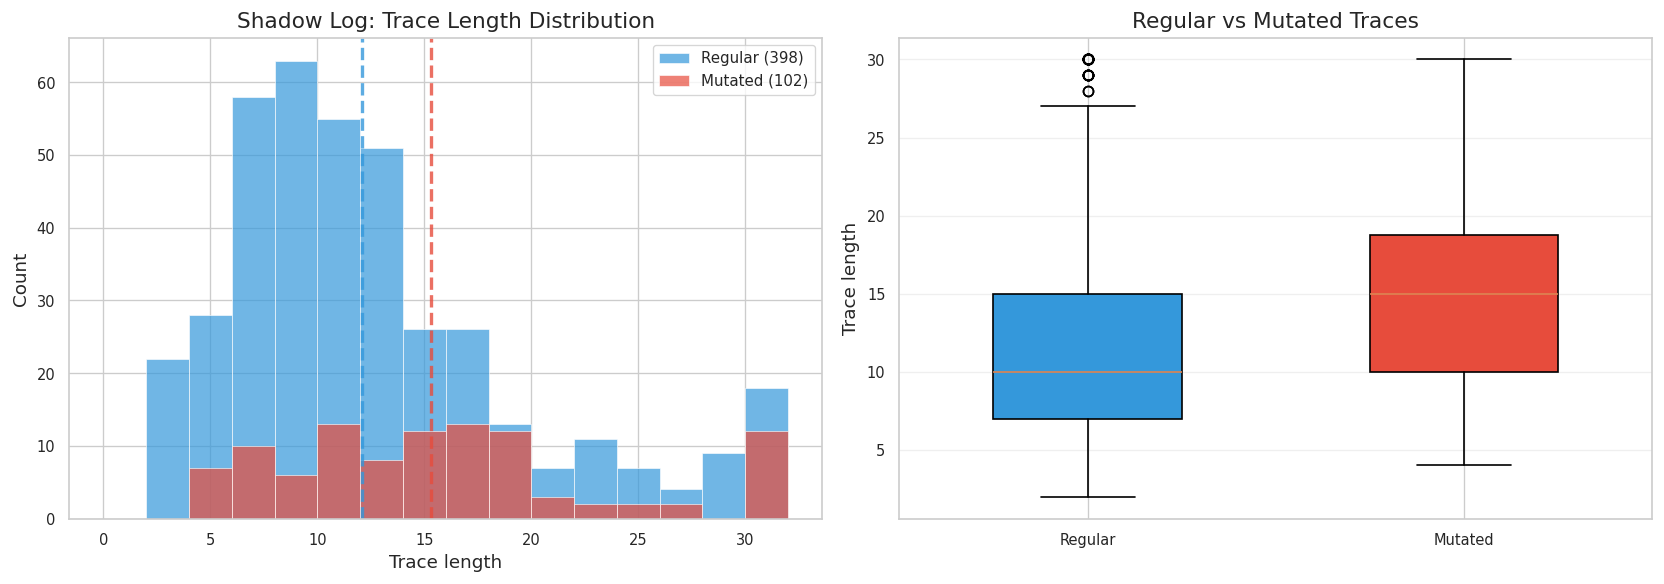

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bins = range(0, max(trace_lens) + 3, 2)
ax.hist(regular_lens, bins=bins, alpha=0.7, label=f'Regular ({len(regular_lens)})',
        color='#3498DB', edgecolor='white', linewidth=0.5)
ax.hist(mutated_lens, bins=bins, alpha=0.7, label=f'Mutated ({len(mutated_lens)})',
        color='#E74C3C', edgecolor='white', linewidth=0.5)
ax.axvline(np.mean(regular_lens), color='#3498DB', ls='--', lw=2, alpha=0.8)
ax.axvline(np.mean(mutated_lens), color='#E74C3C', ls='--', lw=2, alpha=0.8)
ax.set_xlabel('Trace length')
ax.set_ylabel('Count')
ax.set_title('Shadow Log: Trace Length Distribution')
ax.legend(fontsize=9)

ax = axes[1]
box_data = [regular_lens, mutated_lens]
bp = ax.boxplot(box_data, tick_labels=['Regular', 'Mutated'], patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('#3498DB')
bp['boxes'][1].set_facecolor('#E74C3C')
ax.set_ylabel('Trace length')
ax.set_title('Regular vs Mutated Traces')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 5. Example Traces: Regular vs Mutated

Mutated traces contain activities that were never seen in the historical context - this is how the algorithm explores **adversarial** behavior.

In [7]:
print("=" * 70)
print("  REGULAR TRACES (no mutation events)")
print("=" * 70)
seen = 0
for i, (t, m) in enumerate(zip(shadow_log, mutation_flags)):
    if not m and seen < 3:
        seq = [e["concept:name"] for e in t]
        print(f"  #{i}: {' -> '.join(seq)}")
        seen += 1

print()
print("=" * 70)
print("  MUTATED TRACES (contain novel transitions)")
print("=" * 70)
seen = 0
for i, (t, m) in enumerate(zip(shadow_log, mutation_flags)):
    if m and seen < 3:
        seq = [e["concept:name"] for e in t]
        print(f"  #{i}: {' -> '.join(seq)}")
        seen += 1

print()
print(f"Stats for the generated shadow log:")
print(f"  Total traces: {len(shadow_log)}")
print(f"  Mutation rate: {sum(mutation_flags)/len(shadow_log)*100:.1f}%")
print(f"  Avg trace length: {np.mean(trace_lens):.1f} events")

  REGULAR TRACES (no mutation events)
  #0: ER Registration -> ER Triage -> Leucocytes -> CRP -> ER Sepsis Triage
  #1: ER Registration -> ER Sepsis Triage -> ER Triage -> CRP -> Leucocytes -> ER Sepsis Triage -> Admission NC -> IV Liquid -> Release A -> Return ER
  #2: ER Registration -> ER Triage -> CRP -> LacticAcid -> Leucocytes -> IV Antibiotics -> Admission NC -> Admission NC -> Admission NC -> CRP -> Leucocytes -> CRP -> Release B

  MUTATED TRACES (contain novel transitions)
  #14: ER Registration -> ER Sepsis Triage -> ER Triage -> CRP -> LacticAcid -> Leucocytes -> Leucocytes -> Leucocytes -> CRP -> LacticAcid -> LacticAcid -> Release B
  #17: ER Registration -> CRP -> Leucocytes -> LacticAcid -> LacticAcid -> Leucocytes -> Leucocytes -> LacticAcid -> CRP -> LacticAcid -> LacticAcid -> LacticAcid
  #22: ER Registration -> LacticAcid -> CRP -> Leucocytes -> Admission NC -> Admission IC -> Leucocytes -> LacticAcid -> CRP -> LacticAcid -> ER Triage -> ER Sepsis Triage -> IV Anti

## Key Takeaways for Presentation

| Concept | Description |
|---|---|
| **DFS Walker** | Recursively builds trace one activity at a time, maintaining state via call stack |
| **Katz Backoff** | N=3 -> N=2 -> N=1: falls back when states are too sparse (total < 5) or P_unseen = 1.0 |
| **P_unseen** | Good-Turing probability that the next activity is unseen; calculated as N1/N_total |
| **Mutation** | When P_unseen is high, algorithm picks a random activity from the full alphabet |
| **Exploitation** | When P_unseen is low, weighted by log(count+1) to select historically common paths |
| **Termination** | Probabilistic end based on how often the current activity ended traces historically |